# Delivery Operations Analytics

This project analyzes delivery-time patterns using a public delivery operations dataset. I worked on this project to understand how delivery performance changes with traffic, distance, pickup delay, agent rating, area, vehicle type, and product category.

Since my background is in Mechanical Engineering, I treated delivery time like an operations/process-output problem rather than only a dashboard exercise. The goal was to identify practical delivery-time patterns, create useful features, and prepare a cleaned dataset for SQL analysis and Power BI reporting.

This is not a machine learning, route optimization, or real-time tracking project. The dataset does not include promised delivery time or actual road distance, so I used practical proxy features such as slow-delivery flag, straight-line distance, pickup delay, and distance category.

## Quick Summary

- Traffic condition showed one of the clearest differences in delivery time.
- Distance was useful, but traffic and distance together gave a better slow-delivery risk view.
- Pickup delay, agent rating, weekday/weekend, area, vehicle, and category were useful supporting checks.
- Some records had data-quality issues, so I flagged suspicious values instead of deleting everything directly.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## Load and check the data

In [2]:
df = pd.read_csv("../data/amazon_delivery_raw.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (43739, 16)


,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11.30.00,11.45.00,Sunny,High,motorcycle,Urban,120,Clothing
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19.45.00,19.50.00,Stormy,Jam,scooter,Metropolitian,165,Electronics
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,8.30.00,8.45.00,Sandstorms,Low,motorcycle,Urban,130,Sports
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18.00.00,18.10.00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13.30.00,13.45.00,Cloudy,High,scooter,Metropolitian,150,Toys


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43739 entries, 0 to 43738
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         43739 non-null  object 
 1   Agent_Age        43739 non-null  int64  
 2   Agent_Rating     43685 non-null  float64
 3   Store_Latitude   43739 non-null  float64
 4   Store_Longitude  43739 non-null  float64
 5   Drop_Latitude    43739 non-null  float64
 6   Drop_Longitude   43739 non-null  float64
 7   Order_Date       43739 non-null  object 
 8   Order_Time       43739 non-null  object 
 9   Pickup_Time      43739 non-null  object 
 10  Weather          43648 non-null  object 
 11  Traffic          43739 non-null  object 
 12  Vehicle          43739 non-null  object 
 13  Area             43739 non-null  object 
 14  Delivery_Time    43739 non-null  int64  
 15  Category         43739 non-null  object 
dtypes: float64(5), int64(2), object(9)
memory usage: 5.3+ MB


In [4]:
print("Missing values before cleaning:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values before cleaning:
Order_ID            0
Agent_Age           0
Agent_Rating       54
Store_Latitude      0
Store_Longitude     0
Drop_Latitude       0
Drop_Longitude      0
Order_Date          0
Order_Time          0
Pickup_Time         0
Weather            91
Traffic             0
Vehicle             0
Area                0
Delivery_Time       0
Category            0
dtype: int64

Duplicate rows: 0


## Basic cleaning

I kept the cleaning simple because this is a fresher-level analytics project. The aim is to make the data usable without over-processing it.

In [5]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

df.columns

Index(['order_id', 'agent_age', 'agent_rating', 'store_latitude',
       'store_longitude', 'drop_latitude', 'drop_longitude', 'order_date',
       'order_time', 'pickup_time', 'weather', 'traffic', 'vehicle', 'area',
       'delivery_time', 'category'],
      dtype='object')

In [6]:
text_cols = ["weather", "traffic", "vehicle", "area", "category"]

for col in text_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.title()
        .replace(["Nan", "None", "Null", ""], "Unknown")
    )

df["area"] = df["area"].replace({"Metropolitian": "Metropolitan"})

for col in text_cols:
    print(col)
    print(df[col].value_counts().head())
    print("-" * 40)

weather
weather
Fog           7440
Stormy        7374
Cloudy        7288
Sandstorms    7245
Windy         7223
Name: count, dtype: int64
----------------------------------------
traffic
traffic
Low        14999
Jam        13725
Medium     10628
High        4296
Unknown       91
Name: count, dtype: int64
----------------------------------------
vehicle
vehicle
Motorcycle    25527
Scooter       14639
Van            3558
Bicycle          15
Name: count, dtype: int64
----------------------------------------
area
area
Metropolitan    32698
Urban            9751
Other            1138
Semi-Urban        152
Name: count, dtype: int64
----------------------------------------
category
category
Electronics    2849
Books          2824
Jewelry        2802
Toys           2781
Skincare       2772
Name: count, dtype: int64
----------------------------------------


In [7]:
num_cols = [
    "agent_age", "agent_rating", "delivery_time",
    "store_latitude", "store_longitude",
    "drop_latitude", "drop_longitude"
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Agent rating should be within 0 to 5.
# Ratings above 5 are treated as invalid values.
invalid_rating_count = (df["agent_rating"] > 5).sum()
print("Invalid ratings above 5:", invalid_rating_count)

df.loc[df["agent_rating"] > 5, "agent_rating"] = np.nan

# Median fill is simple and suitable for this project.
df["agent_rating"] = df["agent_rating"].fillna(df["agent_rating"].median())

df[["agent_age", "agent_rating", "delivery_time"]].describe()

Invalid ratings above 5: 53


,agent_age,agent_rating,delivery_time
count,43739.000000,43739.000000,43739.000000
mean,29.567137,4.632287,124.905645
std,5.815155,0.331124,51.915451
min,15.000000,1.000000,10.000000
25%,25.000000,4.500000,90.000000
50%,30.000000,4.700000,125.000000
75%,35.000000,4.900000,160.000000
max,50.000000,5.000000,270.000000


## Date, time, and process features

In [8]:
df["order_date"] = pd.to_datetime(
    df["order_date"],
    errors="coerce",
    dayfirst=True
)

# Some time values may use dots instead of colons.
df["order_time"] = (
    df["order_time"]
    .astype(str)
    .str.strip()
    .str.replace(".", ":", regex=False)
)

df["pickup_time"] = (
    df["pickup_time"]
    .astype(str)
    .str.strip()
    .str.replace(".", ":", regex=False)
)

print("Invalid order dates:", df["order_date"].isna().sum())

Invalid order dates: 0


In [44]:
df["order_hour"] = pd.to_datetime(df["order_time"], format="%H:%M:%S", errors="coerce").dt.hour

def get_time_slot(hour):
    if pd.isna(hour):
        return "Unknown"
    elif hour < 12:
        return "Morning"
    elif hour < 17:
        return "Afternoon"
    elif hour < 21:
        return "Evening"
    else:
        return "Night"

df["time_slot"] = df["order_hour"].apply(get_time_slot)

df["day_name"] = df["order_date"].dt.day_name()
df["day_type"] = np.where(
    df["order_date"].isna(),
    "Unknown",
    np.where(df["order_date"].dt.dayofweek >= 5, "Weekend", "Weekday")
)

df[["order_date", "day_name", "day_type", "order_hour", "time_slot"]].head()

,order_date,day_name,day_type,order_hour,time_slot
0,2022-03-19,Saturday,Weekend,11.0,Morning
1,2022-03-25,Friday,Weekday,19.0,Evening
2,2022-03-19,Saturday,Weekend,8.0,Morning
3,2022-04-05,Tuesday,Weekday,18.0,Evening
4,2022-03-26,Saturday,Weekend,13.0,Afternoon


In [45]:
fmt =  "%H:%M:%S"

order_dt = pd.to_datetime(df["order_time"], format=fmt, errors="coerce")
pickup_dt = pd.to_datetime(df["pickup_time"], format=fmt, errors="coerce")

df["pickup_delay_mins"] = (pickup_dt - order_dt).dt.total_seconds() / 60

# Negative pickup delay does not make business sense.
# I kept those values as missing instead of deleting the rows.
df.loc[df["pickup_delay_mins"] < 0, "pickup_delay_mins"] = np.nan

print("Missing pickup delay values:", df["pickup_delay_mins"].isna().sum())
print("Average pickup delay:", round(df["pickup_delay_mins"].mean(), 2))

Missing pickup delay values: 919
Average pickup delay: 9.96


Some pickup delay values could not be calculated because of missing or invalid time values. I kept those rows for delivery-time analysis and used pickup delay only where it was available.

## Distance feature

Distance is calculated from latitude and longitude using Haversine distance. This is straight-line distance, not actual road distance.

In [46]:
def haversine_distance(lat1, lon1, lat2, lon2):
    r = 6371

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return r * c

df["distance_km"] = haversine_distance(
    df["store_latitude"],
    df["store_longitude"],
    df["drop_latitude"],
    df["drop_longitude"]
).round(2)

df[["store_latitude", "store_longitude", "drop_latitude", "drop_longitude", "distance_km"]].head()

,store_latitude,store_longitude,drop_latitude,drop_longitude,distance_km
0,22.745049,75.892471,22.765049,75.912471,3.03
1,12.913041,77.683237,13.043041,77.813237,20.18
2,12.914264,77.678400,12.924264,77.688400,1.55
3,11.003669,76.976494,11.053669,77.026494,7.79
4,12.972793,80.249982,13.012793,80.289982,6.21


In [47]:
df["distance_issue_flag"] = np.where(df["distance_km"] > 30, 1, 0)

print("Distance issue records:", df["distance_issue_flag"].sum())
print("Distance issue percentage:", round(df["distance_issue_flag"].mean() * 100, 2), "%")

Distance issue records: 188
Distance issue percentage: 0.43 %


I did not delete long-distance issue records. Since this is a public dataset, some latitude and longitude values may create unrealistic straight-line distances. I flagged those records and interpreted distance-based insights carefully.

In [48]:
def distance_group(distance):
    if pd.isna(distance):
        return "Unknown"
    elif distance <= 5:
        return "Short"
    elif distance <= 10:
        return "Medium"
    elif distance <= 15:
        return "Long"
    else:
        return "Very Long"

df["distance_category"] = df["distance_km"].apply(distance_group)

df["distance_category"].value_counts()

distance_category
Medium       11759
Long         11754
Short        11722
Very Long     8504
Name: count, dtype: int64

In [49]:
slow_limit = df["delivery_time"].quantile(0.75)

df["slow_delivery_flag"] = np.where(df["delivery_time"] > slow_limit, 1, 0)

print("Slow delivery threshold:", round(slow_limit, 2), "minutes")
print("Slow delivery rate:", round(df["slow_delivery_flag"].mean() * 100, 2), "%")

Slow delivery threshold: 160.0 minutes
Slow delivery rate: 23.05 %


In [50]:
df["rating_group"] = pd.cut(
    df["agent_rating"],
    bins=[0, 3.5, 4.0, 4.5, 5.0],
    labels=["Low", "Average", "Good", "High"],
    include_lowest=True
)

df["rating_group"].value_counts(dropna=False)

rating_group
High       32374
Good        8921
Average     1934
Low          510
Name: count, dtype: int64

## Exploratory analysis

I used a mix of summary tables and charts. I avoided creating the same type of bar chart for every column.

In [51]:
summary = pd.DataFrame({
    "metric": [
        "total_orders",
        "avg_delivery_time",
        "median_delivery_time",
        "avg_distance_km",
        "avg_pickup_delay_mins",
        "slow_delivery_rate"
    ],
    "value": [
        len(df),
        round(df["delivery_time"].mean(), 2),
        round(df["delivery_time"].median(), 2),
        round(df["distance_km"].mean(), 2),
        round(df["pickup_delay_mins"].mean(), 2),
        round(df["slow_delivery_flag"].mean() * 100, 2)
    ]
})

summary

,metric,value
0,total_orders,43739.00
1,avg_delivery_time,124.91
2,median_delivery_time,125.00
3,avg_distance_km,38.56
4,avg_pickup_delay_mins,9.96
5,slow_delivery_rate,23.05


In [52]:
df["delivery_time"].describe()

count    43739.000000
mean       124.905645
std         51.915451
min         10.000000
25%         90.000000
50%        125.000000
75%        160.000000
max        270.000000
Name: delivery_time, dtype: float64

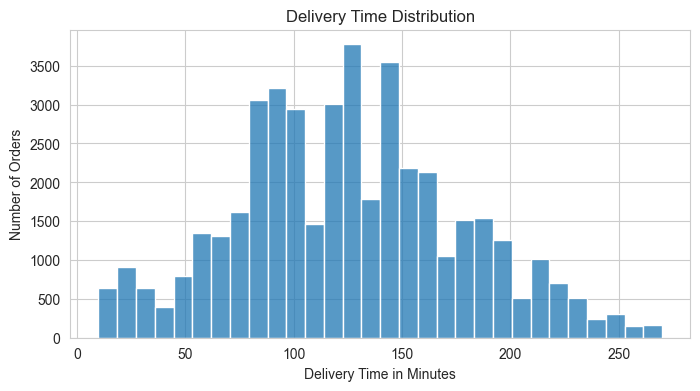

In [53]:
plt.figure(figsize=(8, 4))
sns.histplot(df["delivery_time"], bins=30)
plt.title("Delivery Time Distribution")
plt.xlabel("Delivery Time in Minutes")
plt.ylabel("Number of Orders")
plt.show()

In [54]:
high_delivery_time = df[df["delivery_time"] > 200]

print("Orders above 200 minutes:", len(high_delivery_time))
print("Percentage:", round((len(high_delivery_time) / len(df)) * 100, 2), "%")

high_delivery_time[["order_id", "delivery_time", "traffic", "distance_km", "distance_category"]].head()

Orders above 200 minutes: 3611
Percentage: 8.26 %


,order_id,delivery_time,traffic,distance_km,distance_category
9,bgvc052754213,230,Jam,10.28,Long
13,blhl288691670,205,Jam,19.40,Very Long
17,qfgc848777135,205,Jam,10.76,Long
27,gzfn634029300,235,Jam,13.97,Long
42,ydhu273019158,260,Jam,13.68,Long


Very high delivery-time records were checked separately instead of being removed. They may be real delays or data-quality issues, so I kept them in the dataset and noted them as a limitation.

### Traffic analysis

In [55]:
traffic_avg = (
    df.groupby("traffic")["delivery_time"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
)

traffic_avg

traffic
Jam        147.76
High       129.42
Medium     126.84
Unknown    120.67
Low        101.35
Name: delivery_time, dtype: float64

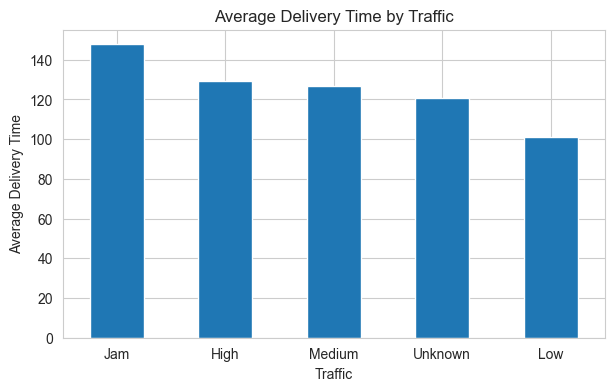

In [56]:
plt.figure(figsize=(7, 4))
traffic_avg.plot(kind="bar")
plt.title("Average Delivery Time by Traffic")
plt.xlabel("Traffic")
plt.ylabel("Average Delivery Time")
plt.xticks(rotation=0)
plt.show()

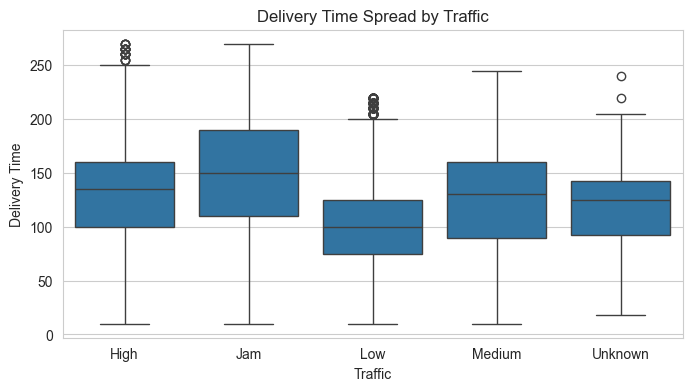

In [57]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="traffic", y="delivery_time")
plt.title("Delivery Time Spread by Traffic")
plt.xlabel("Traffic")
plt.ylabel("Delivery Time")
plt.show()

Traffic was checked using both average delivery time and spread. This is better than relying only on one average value.

### Distance analysis

In [58]:
distance_count = df["distance_category"].value_counts()

distance_count

distance_category
Medium       11759
Long         11754
Short        11722
Very Long     8504
Name: count, dtype: int64

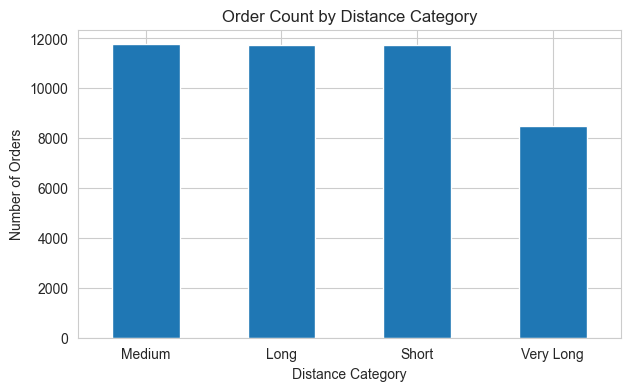

In [59]:
plt.figure(figsize=(7, 4))
distance_count.plot(kind="bar")
plt.title("Order Count by Distance Category")
plt.xlabel("Distance Category")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.show()

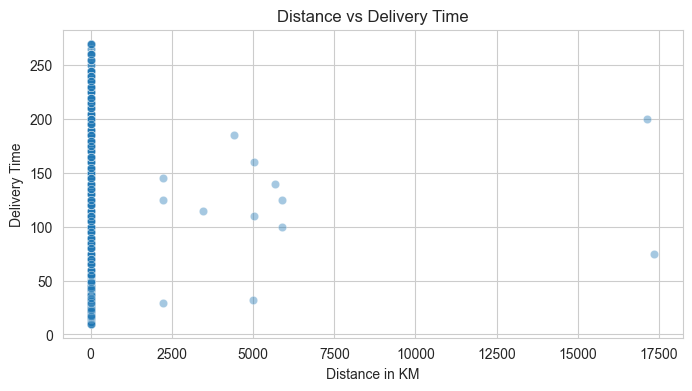

In [60]:
sample_df = df.sample(min(3000, len(df)), random_state=42)

plt.figure(figsize=(8, 4))
sns.scatterplot(
    data=sample_df,
    x="distance_km",
    y="delivery_time",
    alpha=0.4
)
plt.title("Distance vs Delivery Time")
plt.xlabel("Distance in KM")
plt.ylabel("Delivery Time")
plt.show()

Distance and delivery time do not move perfectly together. This is why I checked traffic and distance together instead of using distance alone.

### Traffic and distance together

This is the main business view in the notebook.

In [61]:
traffic_distance = (
    df.groupby(["traffic", "distance_category"])
    .agg(
        orders=("order_id", "count"),
        avg_delivery_time=("delivery_time", "mean"),
        slow_delivery_rate=("slow_delivery_flag", "mean")
    )
    .reset_index()
)

traffic_distance["avg_delivery_time"] = traffic_distance["avg_delivery_time"].round(2)
traffic_distance["slow_delivery_rate"] = (traffic_distance["slow_delivery_rate"] * 100).round(2)

traffic_distance.sort_values("slow_delivery_rate", ascending=False).head(10)

,traffic,distance_category,orders,avg_delivery_time,slow_delivery_rate
3,Jam,Long,5081,159.05,52.25
6,Jam,Very Long,3647,158.91,52.02
11,Medium,Long,3342,142.66,39.02
14,Medium,Very Long,2349,141.96,37.46
15,Unknown,Long,17,118.88,23.53
0,High,Medium,2341,129.79,23.24
1,High,Short,1938,128.92,22.39
4,Jam,Medium,3399,128.11,21.68
5,Jam,Short,1598,128.20,21.21
2,High,Very Long,17,136.88,17.65


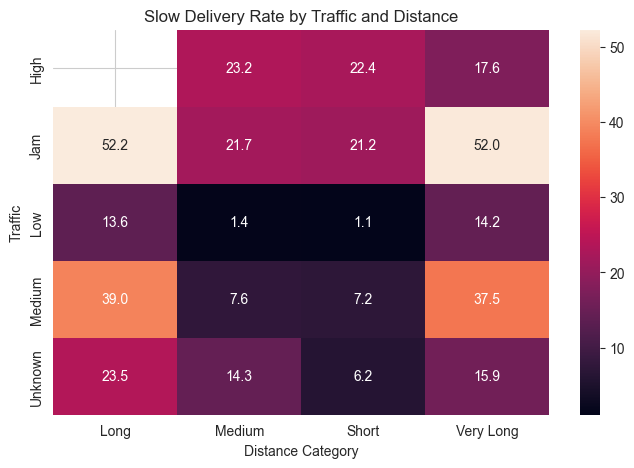

In [62]:
heatmap_data = traffic_distance.pivot(
    index="traffic",
    columns="distance_category",
    values="slow_delivery_rate"
)

plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_data, annot=True, fmt=".1f")
plt.title("Slow Delivery Rate by Traffic and Distance")
plt.xlabel("Distance Category")
plt.ylabel("Traffic")
plt.show()

Traffic and distance together gave the strongest operational view. This is the main risk segment I would use in Power BI.

### Pickup delay analysis

In [63]:
df["pickup_delay_mins"].describe()

count    42820.000000
mean         9.957380
std          4.085477
min          5.000000
25%          5.000000
50%         10.000000
75%         15.000000
max         15.000000
Name: pickup_delay_mins, dtype: float64

In [64]:
pickup_by_slot = df.groupby("time_slot")["pickup_delay_mins"].mean().round(2)

pickup_by_slot

time_slot
Afternoon     9.96
Evening      10.00
Morning       9.97
Night         9.89
Unknown        NaN
Name: pickup_delay_mins, dtype: float64

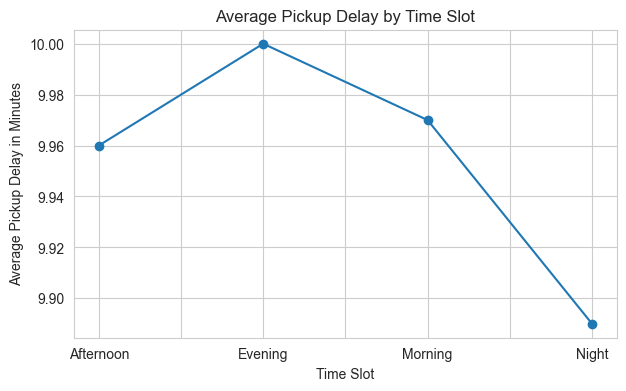

In [65]:
plt.figure(figsize=(7, 4))
pickup_by_slot.plot(kind="line", marker="o")
plt.title("Average Pickup Delay by Time Slot")
plt.xlabel("Time Slot")
plt.ylabel("Average Pickup Delay in Minutes")
plt.show()

Pickup delay is useful as a process KPI, but it should not be treated as the only reason for slow delivery. Delivery time is affected by traffic, distance, and other operating conditions after pickup also.

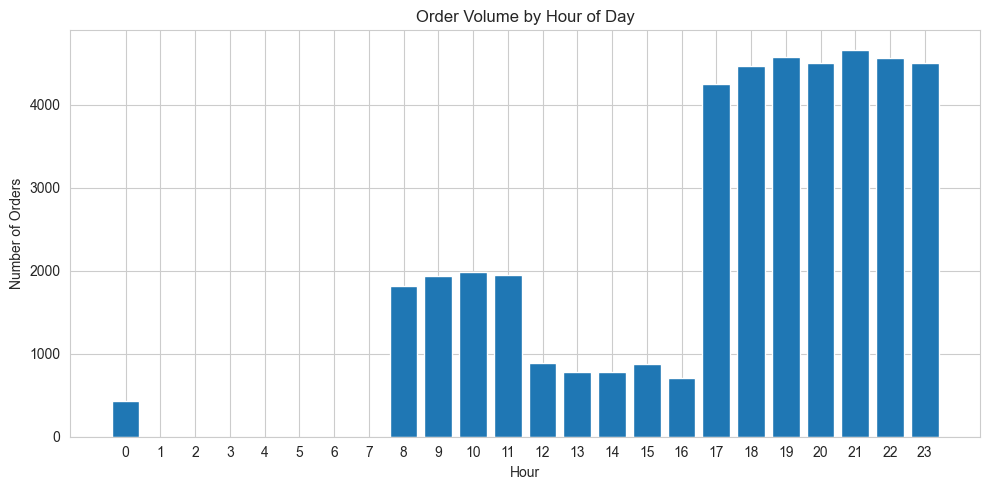

In [66]:
hour_counts = df["order_hour"].value_counts().sort_index()

fig, axes = plt.subplots(1, 1, figsize=(10, 5))

axes.bar(hour_counts.index, hour_counts.values)
axes.set_title("Order Volume by Hour of Day")
axes.set_xlabel("Hour")
axes.set_ylabel("Number of Orders")

axes.set_xticks(range(0, 24))

plt.tight_layout()
plt.show()

### Agent rating analysis

In [67]:
rating_summary = (
    df.groupby("rating_group", observed=False)
    .agg(
        orders=("order_id", "count"),
        avg_delivery_time=("delivery_time", "mean"),
        slow_delivery_rate=("slow_delivery_flag", "mean")
    )
    .reset_index()
)

rating_summary["avg_delivery_time"] = rating_summary["avg_delivery_time"].round(2)
rating_summary["slow_delivery_rate"] = (rating_summary["slow_delivery_rate"] * 100).round(2)

rating_summary

,rating_group,orders,avg_delivery_time,slow_delivery_rate
0,Low,510,171.37,71.18
1,Average,1934,168.53,67.53
2,Good,8921,145.59,42.18
3,High,32374,115.87,14.37


Agent rating was checked as a supporting variable. I did not treat it as a main driver because rating may be influenced by the delivery experience and may not independently explain delivery time.

### Numeric correlation check

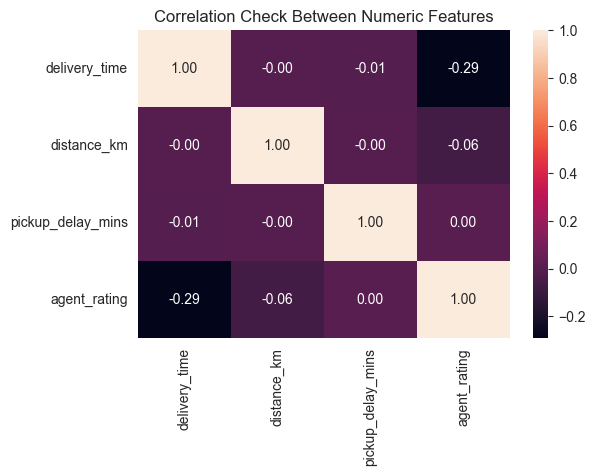

In [68]:
corr_cols = ["delivery_time", "distance_km", "pickup_delay_mins", "agent_rating"]

corr_data = df[corr_cols].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr_data, annot=True, fmt=".2f")
plt.title("Correlation Check Between Numeric Features")
plt.show()

Correlation is used only as a quick numeric check. It does not prove cause, but it helps check whether numeric variables move together.

### Weekday vs weekend check

In [69]:
day_type_summary = (
    df.groupby("day_type")
    .agg(
        orders=("order_id", "count"),
        avg_delivery_time=("delivery_time", "mean"),
        slow_delivery_rate=("slow_delivery_flag", "mean")
    )
    .reset_index()
)

day_type_summary["avg_delivery_time"] = day_type_summary["avg_delivery_time"].round(2)
day_type_summary["slow_delivery_rate"] = (day_type_summary["slow_delivery_rate"] * 100).round(2)

day_type_summary

,day_type,orders,avg_delivery_time,slow_delivery_rate
0,Weekday,31686,124.88,23.05
1,Weekend,12053,124.98,23.07


Weekday and weekend patterns were checked as a simple time-based comparison. I kept this as supporting analysis because traffic and distance gave stronger operational insights.

### Supporting checks

Area, vehicle, and category were checked for context, but not used as the main conclusion.

In [70]:
area_summary = (
    df.groupby("area")
    .agg(
        orders=("order_id", "count"),
        avg_delivery_time=("delivery_time", "mean")
    )
    .round(2)
    .sort_values("avg_delivery_time", ascending=False)
)

area_summary

,orders,avg_delivery_time
area,,
Semi-Urban,152,238.55
Metropolitan,32698,129.70
Urban,9751,109.43
Other,1138,104.46


In [71]:
vehicle_count = df["vehicle"].value_counts()

vehicle_count

vehicle
Motorcycle    25527
Scooter       14639
Van            3558
Bicycle          15
Name: count, dtype: int64

In [72]:
vehicle_count[vehicle_count < 100]

vehicle
Bicycle    15
Name: count, dtype: int64

Some vehicle groups have very low order count, so I avoided making strong vehicle-level conclusions.

In [73]:
category_check = (
    df.groupby("category")
    .agg(
        orders=("order_id", "count"),
        avg_delivery_time=("delivery_time", "mean")
    )
    .round(2)
    .sort_values("avg_delivery_time")
)

category_check.head(10)

,orders,avg_delivery_time
category,,
Grocery,2691,26.54
Toys,2781,129.40
Clothing,2667,130.48
Jewelry,2802,130.75
Electronics,2849,130.84
Home,2685,130.96
Books,2824,131.02
Outdoors,2747,131.06
Shoes,2666,131.15


In [74]:
category_check.tail(10)

,orders,avg_delivery_time
category,,
Books,2824,131.02
Outdoors,2747,131.06
Shoes,2666,131.15
Pet Supplies,2690,131.29
Snacks,2770,131.90
Skincare,2772,132.03
Apparel,2726,132.05
Sports,2719,132.25
Kitchen,2673,132.33


Category-level patterns were checked only for context. Some categories behaved differently, so I did not use category as a main recommendation.

## Final insights and recommendations

In [75]:
# Final insights are generated from the analysis tables above.
# I kept only the main points instead of listing every small observation.

total_orders = len(df)
avg_delivery_time = round(df["delivery_time"].mean(), 2)
slow_rate = round(df["slow_delivery_flag"].mean() * 100, 2)

worst_traffic = traffic_avg.index[0]
worst_traffic_time = traffic_avg.iloc[0]

best_traffic = traffic_avg.index[-1]
best_traffic_time = traffic_avg.iloc[-1]

traffic_gap = round(worst_traffic_time - best_traffic_time, 2)

top_risk_combo = (
    traffic_distance[traffic_distance["orders"] >= 50]
    .sort_values("slow_delivery_rate", ascending=False)
    .iloc[0]
)

high_delivery_count = len(high_delivery_time)
high_delivery_pct = round((high_delivery_count / total_orders) * 100, 2)

missing_pickup = df["pickup_delay_mins"].isna().sum()
missing_pickup_pct = round((missing_pickup / total_orders) * 100, 2)

distance_issue_count = df["distance_issue_flag"].sum()
distance_issue_pct = round((distance_issue_count / total_orders) * 100, 2)

print("FINAL PROJECT INSIGHTS")
print("-" * 60)

print(f"1. The dataset has {total_orders:,} delivery records, with an average delivery time of {avg_delivery_time} minutes.")
print(f"   I used the upper 25% delivery-time threshold to mark slow deliveries. Based on this, around {slow_rate}% of orders were treated as slow-delivery cases.\n")

print(f"2. Traffic showed one of the clearest differences in delivery time.")
print(f"   {worst_traffic} traffic had the highest average delivery time at {worst_traffic_time} minutes,")
print(f"   while {best_traffic} traffic had the lowest average delivery time at {best_traffic_time} minutes.")
print(f"   The gap between them was about {traffic_gap} minutes.\n")

print("3. Distance alone was useful, but traffic and distance together gave a better risk view.")
print(f"   The highest-risk group was {top_risk_combo['traffic']} traffic with {top_risk_combo['distance_category']} distance.")
print(f"   This group had {top_risk_combo['orders']} orders and a slow-delivery rate of {top_risk_combo['slow_delivery_rate']}%.\n")

print("4. Pickup delay was useful as a process metric, but it was not enough to explain delivery time alone.")
print(f"   Pickup delay could not be calculated for {missing_pickup:,} records, which is about {missing_pickup_pct}% of the dataset.")
print("   So I used pickup delay as a supporting KPI instead of making it the main reason for slow delivery.\n")

print("5. Very high delivery-time records were checked separately.")
print(f"   There were {high_delivery_count:,} orders above 200 minutes, which is about {high_delivery_pct}% of all records.")
print("   I kept these records because they may represent real delays or data-quality issues.\n")

print("6. Some location records looked unrealistic based on straight-line distance.")
print(f"   I flagged {distance_issue_count:,} records as distance issue cases, around {distance_issue_pct}% of the dataset.")
print("   I did not delete them directly because public datasets can contain location-quality problems.")

FINAL PROJECT INSIGHTS
------------------------------------------------------------
1. The dataset has 43,739 delivery records, with an average delivery time of 124.91 minutes.
   I used the upper 25% delivery-time threshold to mark slow deliveries. Based on this, around 23.05% of orders were treated as slow-delivery cases.

2. Traffic showed one of the clearest differences in delivery time.
   Jam traffic had the highest average delivery time at 147.76 minutes,
   while Low traffic had the lowest average delivery time at 101.35 minutes.
   The gap between them was about 46.41 minutes.

3. Distance alone was useful, but traffic and distance together gave a better risk view.
   The highest-risk group was Jam traffic with Long distance.
   This group had 5081 orders and a slow-delivery rate of 52.25%.

4. Pickup delay was useful as a process metric, but it was not enough to explain delivery time alone.
   Pickup delay could not be calculated for 919 records, which is about 2.1% of the da

In [76]:
print("BUSINESS OBSERVATIONS")
print("-" * 50)

print("1. Traffic condition had a clear impact on delivery time.")
print("   Jam or High traffic orders should be monitored separately.")

print("\n2. Distance became more useful when combined with traffic.")
print("   Long-distance orders under difficult traffic can be treated as higher-risk deliveries.")

print("\n3. Pickup delay is useful as a process KPI.")
print("   But it should not be treated as the only reason for slow deliveries.")

print("\n4. Agent rating, weekday/weekend, area, vehicle, and category were useful supporting checks.")
print("   But they should be interpreted carefully and not used for unsupported conclusions.")

print("\n5. Very high delivery-time and distance issue records should be reviewed separately.")
print("   I flagged these cases instead of deleting them directly.")

BUSINESS OBSERVATIONS
--------------------------------------------------
1. Traffic condition had a clear impact on delivery time.
   Jam or High traffic orders should be monitored separately.

2. Distance became more useful when combined with traffic.
   Long-distance orders under difficult traffic can be treated as higher-risk deliveries.

3. Pickup delay is useful as a process KPI.
   But it should not be treated as the only reason for slow deliveries.

4. Agent rating, weekday/weekend, area, vehicle, and category were useful supporting checks.
   But they should be interpreted carefully and not used for unsupported conclusions.

5. Very high delivery-time and distance issue records should be reviewed separately.
   I flagged these cases instead of deleting them directly.


## Limitations

- The dataset does not include promised delivery time, so slow delivery was defined using the 75th percentile.
- Distance was calculated using the Haversine formula, so it is straight-line distance and not actual road distance.
- Some location records may have data-quality issues, so I flagged unrealistic distance records instead of deleting them.
- Some pickup delay values could not be calculated because of missing or invalid time values.
- Agent rating may be affected by delivery experience, so it should not be treated as a direct cause of delay.
- Some vehicle and category groups had unusual patterns, so I treated them carefully.
- This project identifies delivery-time patterns, but it does not prove the exact cause of delay.

## Conclusion

This analysis showed that delivery performance is not explained by one factor alone. Traffic condition was one of the clearest factors, but the combination of traffic and distance gave a stronger view of slow-delivery risk.

Pickup delay, agent rating, weekday/weekend, area, vehicle, and category were useful supporting checks, but they were not strong enough to be treated as the main drivers.

The main learning from this project was handling imperfect public data carefully: creating practical features, checking outliers, flagging suspicious distance records, and avoiding unsupported conclusions.

## Export cleaned data

The cleaned dataset is exported for SQL analysis and Power BI dashboard creation.

In [77]:
import os

os.makedirs("../data/processed", exist_ok=True)

df.to_csv("../data/processed/delivery_operations_cleaned.csv", index=False)

print("Cleaned dataset exported successfully.")
print("Final shape:", df.shape)

Cleaned dataset exported successfully.
Final shape: (43739, 26)


In [78]:
df[
    [
        "delivery_time",
        "distance_km",
        "distance_category",
        "slow_delivery_flag",
        "pickup_delay_mins",
        "traffic",
        "day_type",
        "rating_group"
    ]
].head()

,delivery_time,distance_km,distance_category,slow_delivery_flag,pickup_delay_mins,traffic,day_type,rating_group
0,120,3.03,Short,0,15.0,High,Weekend,High
1,165,20.18,Very Long,1,5.0,Jam,Weekday,Good
2,130,1.55,Short,0,15.0,Low,Weekend,Good
3,105,7.79,Medium,0,10.0,Medium,Weekday,High
4,150,6.21,Medium,0,15.0,High,Weekend,High
